In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

os.environ["USE_PYGEOS"] = "0"
import geopandas as gpd

sys.path.append("..")
sys.path.append("../..")
from src.paper_analysis_hydropower import (
    NationalAnalysisHydropower,
    plot_pre_post_bias_correction_validation,
)
from src import data_processing_projections
from src.data_processing_projections import DataProcessingDask

from src.utils_polygons import (
    find_upstream_polygons_recursive,
    flatten_list,
    get_points_in_polygons,
    build_prevah_grid_points,
    build_prevah_grid_cells,
    map_polygons_to_grid_by_intersection,
    fill_missing_polygons_by_nearest,
)

from src.utils_streamflow_hydropower import (
    GRAVITY,
    WATER_DENSITY,
    compute_ds_hydropower_generation_from_streamflow,
    compute_simplified_efficiency_term,
    aggregate_streamflow_with_mask,
    concat_list_ds_and_save,
    convert_mm_d_to_cubic_m_s,
    build_hydropower_parameter_table,
    build_polygon_plant_weights,
    aggregate_polygon_to_plant_flow,
    compute_hydropower_production_vectorized,
    mode_of,
)
from src.extract_runoff_prevah import transform_coords_old_to_new_swiss
import dask
from dask.diagnostics import ProgressBar

import matplotlib.pyplot as plt

In [3]:
paths = json.load(open("../paths_projections.json"))

path_data = Path(paths["path_data_ror"])

path_data_hydro = path_data / "hydropower"
path_data_polygons = path_data / "polygons"
path_swiss_maps = path_data / "maps" / "swissboundaries3d_2023-01_2056_5728/"

path_figs = Path(paths["path_figs"])

In [4]:
dask.config.set(num_workers=15, threads_per_worker=16)
dask.config.set(
    {
        "distributed.worker.memory.target": 0.7,  # Spill to disk at 70%
        "distributed.worker.memory.spill": 0.8,  # Start spilling at 80%
        "distributed.worker.memory.pause": 0.9,  # Pause worker at 90%
        "array.chunk-size": "512MiB",
        "logging.distributed": "error",  # Less verbose logs
    }
)

In [5]:
# climate_model_chain = None
# climate_scenario = None

climate_model_chain = "CNRM-ALADIN63_CNRM-CERFACS-CNRM-CM5_r1i1p1"
climate_scenario = "rcp26"

In [6]:
prevah_grid_resolution = 500  # in meters

In [ ]:
processing = DataProcessingDask(
    "../../paths_projections.json", climate_model_chain, climate_scenario
)

Loading data


In [8]:
if climate_model_chain is None and climate_scenario is None:
    df_prevah_pts_in_polygons_filename = "df_prevah_obs_pts_in_polygons.csv"
else:
    df_prevah_pts_in_polygons_filename = "df_prevah_proj_pts_in_polygons.csv"

if processing.weighted:
    df_prevah_pts_in_polygons_filename = (
        df_prevah_pts_in_polygons_filename.removesuffix(".csv") + "_weighted.csv"
    )

# Compute hydropower

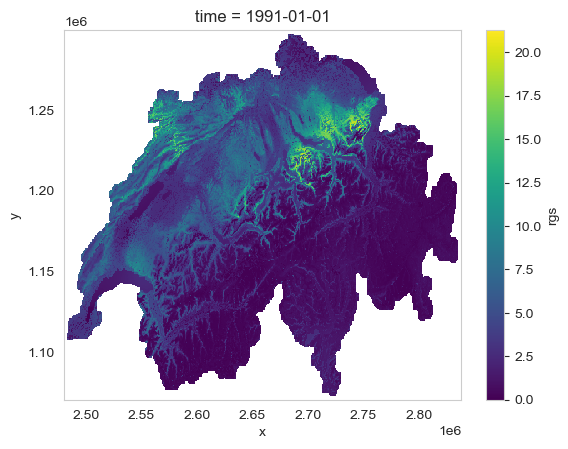

In [13]:
path_rgs = processing.path_data_prevah / "rgs.zarr"
xr.open_zarr(path_rgs, chunks="auto").isel(time=0).rgs.plot()

## Create point in polygon matching

In [ ]:
# processing.extract_points_in_polygons()

## PREVAH polygon grid

### Compare with old method

The old method computed the accumulated streamflow per polygon, meaning that we don't go through getting the per grid point matching with a polygon, but rather for each polygon we get the points that match with it. That means that when a polygon does not have an intersecting point, it will take the nearest one to it. This sometimes happens because of the shape of the polygons. It means that a point can contribute to multiple polygons. With the new method, a point can only contribute to one polygon, leaving more than 1000 polygons without a point assigned to it.

An option is to switch to a sparse matrix to have a point contributing to multiple polygons.

In [14]:
df_prevah_pts_in_polygons = pd.read_csv(
    processing.path_data_polygons / df_prevah_pts_in_polygons_filename
)

In [ ]:
df_prevah_pts_in_polygons_old = pd.read_csv(
    "/landclim/yhaddad/papers/paper1_clim2ror/data/polygons/df_prevah_500_pts_in_polygons.csv"
)

In [ ]:
df_prevah_pts_in_polygons_proj = pd.read_csv(
    "/landclim/yhaddad/hydropower/hydropower_projections/ror/polygons/df_prevah_proj_pts_in_polygons.csv"
)

Found 1419 missing EZGNR(s). Example: [163840, 172032, 163844, 172038, 155658, 106507, 155669, 114714, 172071, 172072]


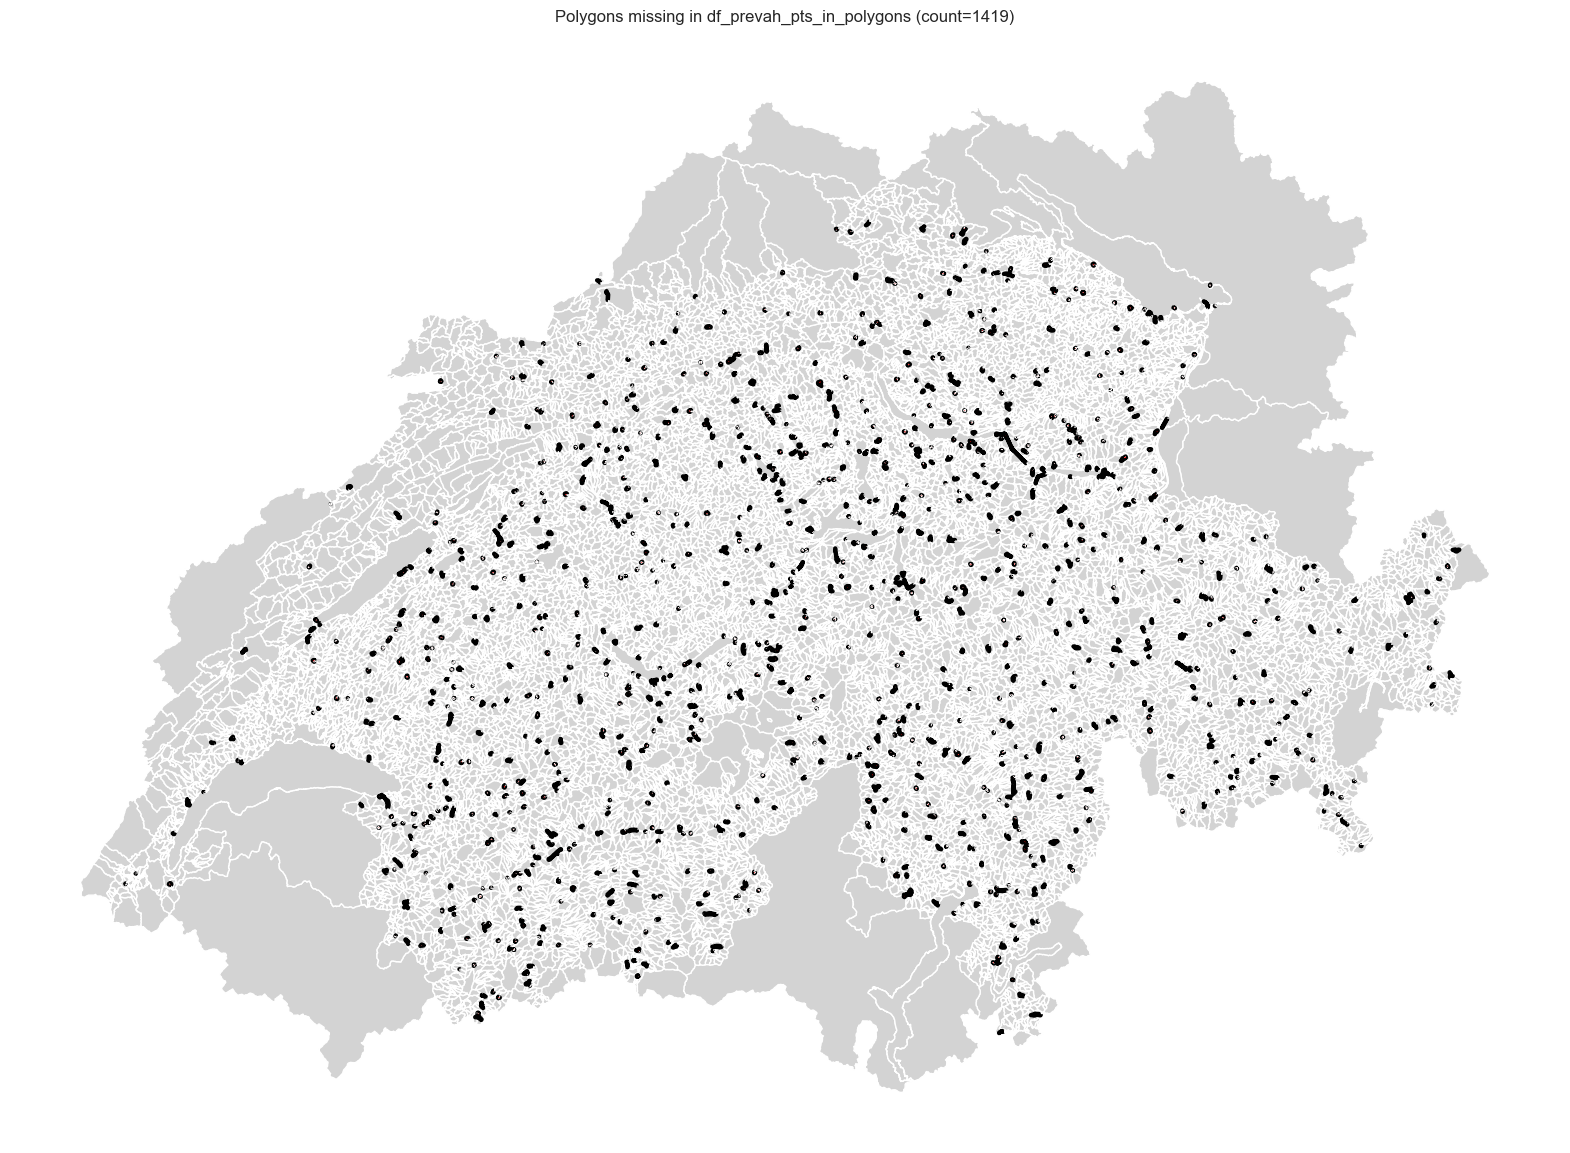

In [ ]:
import numpy as np

# find EZGNRs present in the old dataframe but missing in the current one,
# then plot those polygons from the available gdf (processing.gdf_polygons).

import matplotlib.pyplot as plt

# normalize to integers (drop NaNs if any)
missing_ezg = list(
    set(processing.gdf_polygons["EZGNR"].unique())
    - set(df_prevah_pts_in_polygons["EZGNR"].unique())
)
print(f"Found {len(missing_ezg)} missing EZGNR(s). Example: {missing_ezg[:10]}")

# subset polygon GeoDataFrame
gdf_polygons = processing.gdf_polygons  # available in the notebook
gdf_missing = gdf_polygons[gdf_polygons["EZGNR"].isin(missing_ezg)]

# plot
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
gdf_polygons.plot(ax=ax, color="lightgrey", edgecolor="white")
if not gdf_missing.empty:
    gdf_missing.plot(ax=ax, color="red", edgecolor="black", linewidth=3)
    ax.set_title(
        f"Polygons missing in df_prevah_pts_in_polygons (count={len(missing_ezg)})"
    )
else:
    ax.set_title("No missing polygons found")
ax.set_axis_off()
plt.show()

In [ ]:
gdf_polygons[gdf_polygons["EZGNR"].isin(missing_ezg)].geometry.area / 1e6

9        0.066958
32       0.020130
40       0.075241
47       0.003545
51       0.022618
           ...   
21802    0.114260
21803    0.051379
21845    0.206759
21847    0.038240
21848    0.097302
Length: 1419, dtype: float64

In [ ]:
prevah_grid_resolution = 500  # in meters
ds_sample = xr.open_zarr(processing.path_data_prevah / "rgs.zarr", chunks="auto")

# Transform a sample runoff grid into a GeoDataFrame to use operations included in GeoPandas
df_runoff = ds_sample.isel(time=0)
new_x = (
    np.round(df_runoff.x.values / prevah_grid_resolution) * prevah_grid_resolution
).astype(df_runoff.x.dtype)
new_y = (
    np.round(df_runoff.y.values / prevah_grid_resolution) * prevah_grid_resolution
).astype(df_runoff.y.dtype)
df_runoff = df_runoff.assign_coords(x=new_x, y=new_y)
df_runoff = df_runoff.to_dataframe().reset_index()

gdf_runoff = gpd.GeoDataFrame(
    df_runoff,
    geometry=gpd.points_from_xy(df_runoff.x, df_runoff.y),
    crs="EPSG:2056",
)[["y", "x", "geometry"]]
del ds_sample

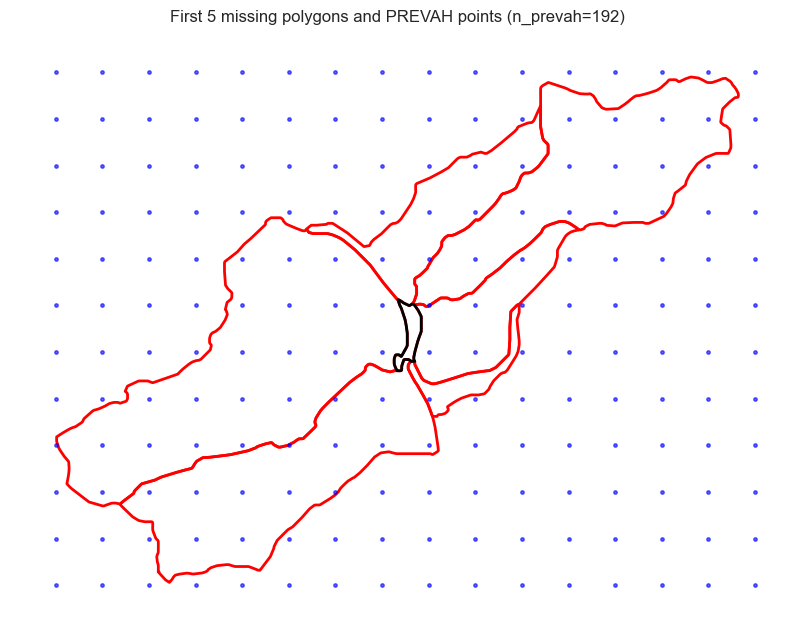

In [ ]:
# plot first 5 missing polygons and overlay runoff points within their bounding box
gdf_sel = gdf_polygons[gdf_polygons["EZGNR"] == missing_ezg[120]]

if gdf_sel.empty:
    print("No polygons selected.")
else:
    minx, miny, maxx, maxy = gdf_sel.total_bounds

    # filter runoff points to the polygon bounding box to avoid plotting all ~300k points
    gdf_runoff_sub = gdf_runoff[
        (gdf_runoff["x"] >= minx - 500)
        & (gdf_runoff["x"] <= maxx + 500)
        & (gdf_runoff["y"] >= miny - 500)
        & (gdf_runoff["y"] <= maxy + 500)
    ]
    # find neighboring polygons that touch or are within one grid cell (500 m) of the selected polygon(s)
    sel_union = gdf_sel.geometry.unary_union
    buffer = prevah_grid_resolution  # 500 m

    # use spatial index to limit candidates to those whose bbox intersects an expanded bbox around the selection
    minx_sel, miny_sel, maxx_sel, maxy_sel = gdf_sel.total_bounds
    bounds = (
        minx_sel - buffer,
        miny_sel - buffer,
        maxx_sel + buffer,
        maxy_sel + buffer,
    )
    candidate_idx = list(gdf_polygons.sindex.intersection(bounds))
    gdf_candidates = gdf_polygons.iloc[candidate_idx]

    # neighbors are those that touch the selection or lie within the buffer distance
    gdf_neighbors = gdf_candidates[
        gdf_candidates.geometry.touches(sel_union)
        | (gdf_candidates.geometry.distance(sel_union) <= buffer)
    ]

    # exclude already selected polygons and append neighbors to gdf_sel
    gdf_neighbors = gdf_neighbors[~gdf_neighbors.index.isin(gdf_sel.index)]
    gdf_pol_all = pd.concat([gdf_sel, gdf_neighbors], ignore_index=True)

    # recompute bounding box and runoff subset to reflect the expanded selection
    minx, miny, maxx, maxy = gdf_pol_all.total_bounds
    gdf_runoff_sub = gdf_runoff[
        (gdf_runoff["x"] >= minx - 500)
        & (gdf_runoff["x"] <= maxx + 500)
        & (gdf_runoff["y"] >= miny - 500)
        & (gdf_runoff["y"] <= maxy + 500)
    ]
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf_neighbors.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    gdf_sel.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        label="Selected polygon",
    )
    if not gdf_runoff_sub.empty:
        gdf_runoff_sub.plot(ax=ax, markersize=6, color="blue", alpha=0.6)
    ax.set_title(
        f"First 5 missing polygons and PREVAH points (n_prevah={len(gdf_runoff_sub)})"
    )
    ax.set_xlim(minx - 500, maxx + 500)
    ax.set_ylim(miny - 500, maxy + 500)
    ax.set_axis_off()
    plt.show()

### Intersection with area weighting

#### Test

In [33]:
import shapely.geometry as geom

prevah_grid_resolution = 500  # in meters
ds_sample = xr.open_zarr(processing.path_data_prevah / "rgs.zarr", chunks="auto")

# Transform a sample runoff grid into a GeoDataFrame to use operations included in GeoPandas
df_runoff = ds_sample.isel(time=0)
new_x = (
    np.round(df_runoff.x.values / prevah_grid_resolution) * prevah_grid_resolution
).astype(df_runoff.x.dtype)
new_y = (
    np.round(df_runoff.y.values / prevah_grid_resolution) * prevah_grid_resolution
).astype(df_runoff.y.dtype)

cells = []
half = prevah_grid_resolution / 2.0
for y in new_y:
    for x in new_x:
        cells.append(
            {
                "x": x,
                "y": y,
                "geometry": geom.box(x - half, y - half, x + half, y + half),
            }
        )
gdf_runoff_boxes = gpd.GeoDataFrame(cells, crs="EPSG:2056")

del ds_sample

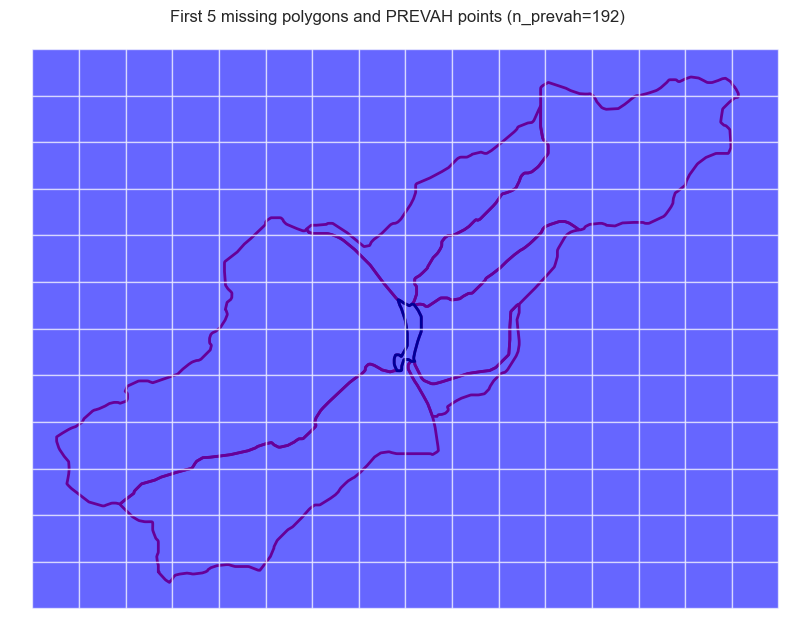

In [ ]:
# plot first 5 missing polygons and overlay runoff points within their bounding box
gdf_sel = gdf_polygons[gdf_polygons["EZGNR"] == missing_ezg[120]]

if gdf_sel.empty:
    print("No polygons selected.")
else:
    minx, miny, maxx, maxy = gdf_sel.total_bounds

    # filter runoff points to the polygon bounding box to avoid plotting all ~300k points
    gdf_runoff_sub = gdf_runoff_boxes[
        (gdf_runoff_boxes["x"] >= minx - 500)
        & (gdf_runoff_boxes["x"] <= maxx + 500)
        & (gdf_runoff_boxes["y"] >= miny - 500)
        & (gdf_runoff_boxes["y"] <= maxy + 500)
    ]
    # find neighboring polygons that touch or are within one grid cell (500 m) of the selected polygon(s)
    sel_union = gdf_sel.geometry.unary_union
    buffer = prevah_grid_resolution  # 500 m

    # use spatial index to limit candidates to those whose bbox intersects an expanded bbox around the selection
    minx_sel, miny_sel, maxx_sel, maxy_sel = gdf_sel.total_bounds
    bounds = (
        minx_sel - buffer,
        miny_sel - buffer,
        maxx_sel + buffer,
        maxy_sel + buffer,
    )
    candidate_idx = list(gdf_polygons.sindex.intersection(bounds))
    gdf_candidates = gdf_polygons.iloc[candidate_idx]

    # neighbors are those that touch the selection or lie within the buffer distance
    gdf_neighbors = gdf_candidates[
        gdf_candidates.geometry.touches(sel_union)
        | (gdf_candidates.geometry.distance(sel_union) <= buffer)
    ]

    # exclude already selected polygons and append neighbors to gdf_sel
    gdf_neighbors = gdf_neighbors[~gdf_neighbors.index.isin(gdf_sel.index)]
    gdf_pol_all = pd.concat([gdf_sel, gdf_neighbors], ignore_index=True)

    # recompute bounding box and runoff subset to reflect the expanded selection
    minx, miny, maxx, maxy = gdf_pol_all.total_bounds
    gdf_runoff_sub = gdf_runoff_boxes[
        (gdf_runoff_boxes["x"] >= minx - 500)
        & (gdf_runoff_boxes["x"] <= maxx + 500)
        & (gdf_runoff_boxes["y"] >= miny - 500)
        & (gdf_runoff_boxes["y"] <= maxy + 500)
    ]
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf_neighbors.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    gdf_sel.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        label="Selected polygon",
    )
    if not gdf_runoff_sub.empty:
        gdf_runoff_sub.plot(ax=ax, markersize=6, color="blue", alpha=0.6)
    ax.set_title(
        f"First 5 missing polygons and PREVAH points (n_prevah={len(gdf_runoff_sub)})"
    )
    ax.set_xlim(minx - 500, maxx + 500)
    ax.set_ylim(miny - 500, maxy + 500)
    ax.set_axis_off()
    plt.show()

In [ ]:
map_polygons_to_grid_by_intersection(gdf_sel, gdf_runoff_boxes, min_fraction=0.0)

,x,y,EZGNR,cell_area,intersect_area,weight
0,2693000.0,1185000.0,156273,250000.0,7159.444864,0.028638
1,2693500.0,1185000.0,156273,250000.0,38962.279863,0.155849
2,2693000.0,1184500.0,156273,250000.0,15887.126847,0.063549
3,2693500.0,1184500.0,156273,250000.0,38854.447226,0.155418


In [ ]:
map_polygons_to_grid_by_intersection(gdf_neighbors, gdf_runoff_boxes, min_fraction=0.01)

,x,y,EZGNR,cell_area,intersect_area,weight
0,2694500.0,1187500.0,193501,250000.0,5341.453757,0.021366
1,2695000.0,1187500.0,193501,250000.0,34370.490466,0.137482
2,2696000.0,1187500.0,193501,250000.0,47568.665602,0.190275
3,2696500.0,1187500.0,193501,250000.0,84968.574363,0.339874
4,2697000.0,1187500.0,193501,250000.0,5666.173293,0.022665
...,...,...,...,...,...,...
111,2691500.0,1182500.0,161203,250000.0,250000.000000,1.000000
112,2692000.0,1182500.0,161203,250000.0,89715.557896,0.358862
113,2690500.0,1182000.0,161203,250000.0,26724.228627,0.106897
114,2691000.0,1182000.0,161203,250000.0,55068.051225,0.220272


#### Check

In [73]:
df_prevah_pts_in_polygons = pd.read_csv(
    processing.path_data_polygons / df_prevah_pts_in_polygons_filename
)

Found 0 missing EZGNR(s). Example: []


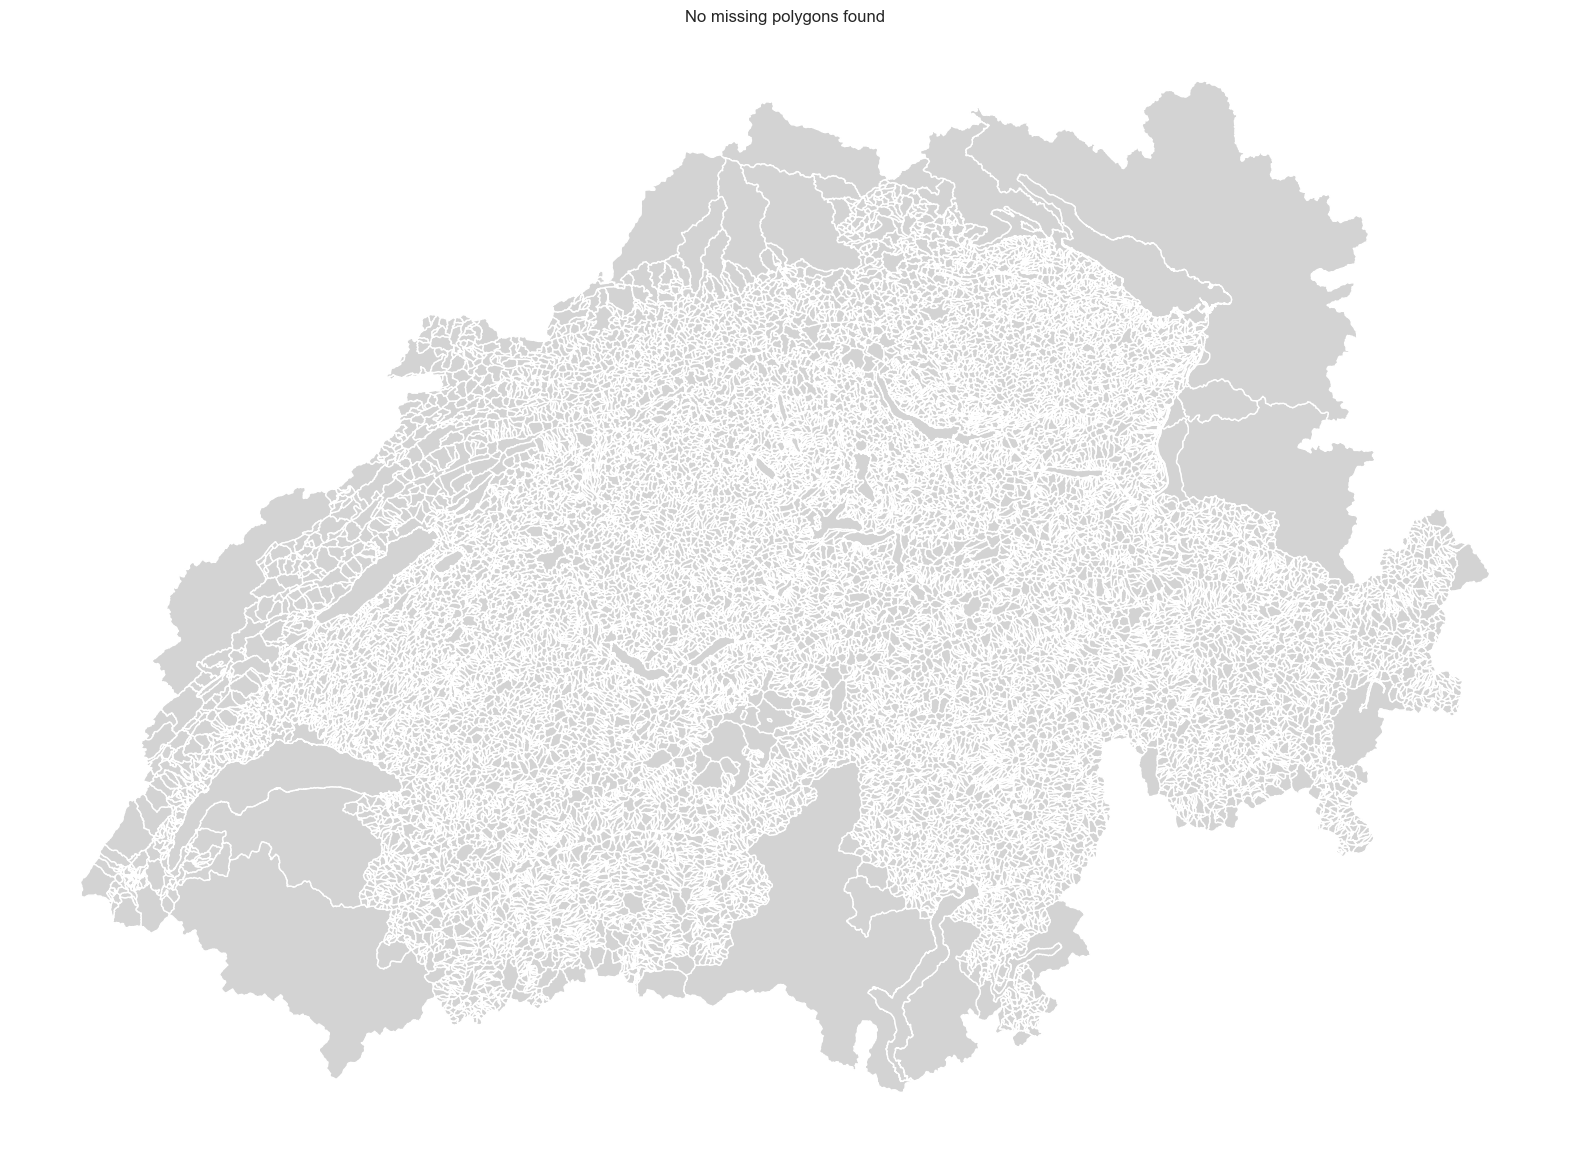

In [74]:
import numpy as np

# find EZGNRs present in the old dataframe but missing in the current one,
# then plot those polygons from the available gdf (processing.gdf_polygons).

import matplotlib.pyplot as plt

# normalize to integers (drop NaNs if any)
missing_ezg = list(
    set(processing.gdf_polygons["EZGNR"].unique())
    - set(df_prevah_pts_in_polygons["EZGNR"].unique())
)
print(f"Found {len(missing_ezg)} missing EZGNR(s). Example: {missing_ezg[:10]}")

# subset polygon GeoDataFrame
gdf_polygons = processing.gdf_polygons  # available in the notebook
gdf_missing = gdf_polygons[gdf_polygons["EZGNR"].isin(missing_ezg)]

# plot
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
gdf_polygons.plot(ax=ax, color="lightgrey", edgecolor="white")
if not gdf_missing.empty:
    gdf_missing.plot(ax=ax, color="red", edgecolor="black", linewidth=3)
    ax.set_title(
        f"Polygons missing in df_prevah_pts_in_polygons (count={len(missing_ezg)})"
    )
else:
    ax.set_title("No missing polygons found")
ax.set_axis_off()
plt.show()

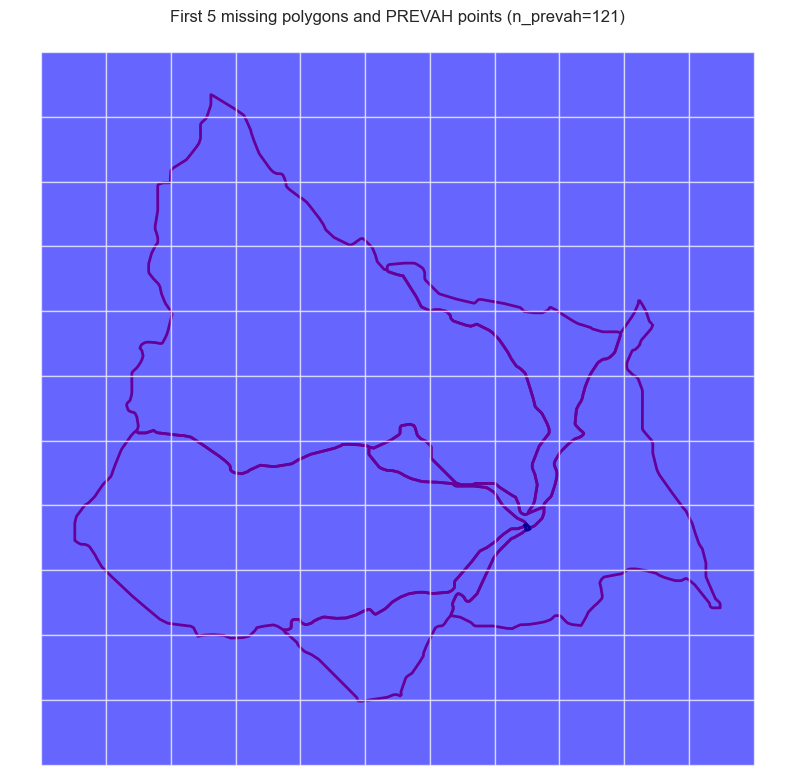

In [34]:
# plot first 5 missing polygons and overlay runoff points within their bounding box
gdf_sel = gdf_polygons[gdf_polygons["EZGNR"] == missing_ezg[0]]

if gdf_sel.empty:
    print("No polygons selected.")
else:
    minx, miny, maxx, maxy = gdf_sel.total_bounds

    # filter runoff points to the polygon bounding box to avoid plotting all ~300k points
    gdf_runoff_sub = gdf_runoff_boxes[
        (gdf_runoff_boxes["x"] >= minx - 500)
        & (gdf_runoff_boxes["x"] <= maxx + 500)
        & (gdf_runoff_boxes["y"] >= miny - 500)
        & (gdf_runoff_boxes["y"] <= maxy + 500)
    ]
    # find neighboring polygons that touch or are within one grid cell (500 m) of the selected polygon(s)
    sel_union = gdf_sel.geometry.unary_union
    buffer = prevah_grid_resolution  # 500 m

    # use spatial index to limit candidates to those whose bbox intersects an expanded bbox around the selection
    minx_sel, miny_sel, maxx_sel, maxy_sel = gdf_sel.total_bounds
    bounds = (
        minx_sel - buffer,
        miny_sel - buffer,
        maxx_sel + buffer,
        maxy_sel + buffer,
    )
    candidate_idx = list(gdf_polygons.sindex.intersection(bounds))
    gdf_candidates = gdf_polygons.iloc[candidate_idx]

    # neighbors are those that touch the selection or lie within the buffer distance
    gdf_neighbors = gdf_candidates[
        gdf_candidates.geometry.touches(sel_union)
        | (gdf_candidates.geometry.distance(sel_union) <= buffer)
    ]

    # exclude already selected polygons and append neighbors to gdf_sel
    gdf_neighbors = gdf_neighbors[~gdf_neighbors.index.isin(gdf_sel.index)]
    gdf_pol_all = pd.concat([gdf_sel, gdf_neighbors], ignore_index=True)

    # recompute bounding box and runoff subset to reflect the expanded selection
    minx, miny, maxx, maxy = gdf_pol_all.total_bounds
    gdf_runoff_sub = gdf_runoff_boxes[
        (gdf_runoff_boxes["x"] >= minx - 500)
        & (gdf_runoff_boxes["x"] <= maxx + 500)
        & (gdf_runoff_boxes["y"] >= miny - 500)
        & (gdf_runoff_boxes["y"] <= maxy + 500)
    ]
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf_neighbors.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    gdf_sel.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        label="Selected polygon",
    )
    if not gdf_runoff_sub.empty:
        gdf_runoff_sub.plot(ax=ax, markersize=6, color="blue", alpha=0.6)
    ax.set_title(
        f"First 5 missing polygons and PREVAH points (n_prevah={len(gdf_runoff_sub)})"
    )
    ax.set_xlim(minx - 500, maxx + 500)
    ax.set_ylim(miny - 500, maxy + 500)
    ax.set_axis_off()
    plt.show()

In [32]:
df_prevah_pts_in_polygons[df_prevah_pts_in_polygons["weight"] > 0.8]

,x,y,EZGNR,cell_area,intersect_area,weight,index_left
2,2703500.0,1137000.0,100001,250000.0,236759.455108,0.947038,14
6,2703500.0,1137500.0,100001,250000.0,212834.798526,0.851339,18
7,2704000.0,1137500.0,100001,250000.0,250000.000000,1.000000,19
8,2704500.0,1137500.0,100001,250000.0,250000.000000,1.000000,20
11,2703500.0,1138000.0,100001,250000.0,205703.958913,0.822816,1
...,...,...,...,...,...,...,...
399944,2618000.0,1216500.0,199993,250000.0,241600.467262,0.966402,399955
399947,2618000.0,1217000.0,199993,250000.0,235471.662462,0.941887,399947
399948,2618500.0,1217000.0,199993,250000.0,249964.823836,0.999859,399963
399956,2619500.0,1217500.0,199993,250000.0,202683.583711,0.810734,399945


In [ ]:
grid_cells_present = df_prevah_pts_in_polygons.groupby(["x", "y"]).agg(
    {"EZGNR": list, "weight": "sum"}
)

In [87]:
grid_cells_present[grid_cells_present["weight"] == 1.0]

EZGNR  weight
x         y                          
2481000.0 1112500.0  [123386]     1.0
          1113000.0  [123386]     1.0
          1113500.0  [123386]     1.0
          1114000.0  [123386]     1.0
          1114500.0  [123386]     1.0
...                       ...     ...
2838000.0 1196000.0  [120431]     1.0
          1196500.0  [120431]     1.0
          1197000.0  [120431]     1.0
          1197500.0  [120431]     1.0
          1198000.0  [120431]     1.0

[144883 rows x 2 columns]

In [ ]:
print(
    "% of grid cells covered: ", round(len(grid_cells_present) / (715 * 429), 4) * 100
)

% of grid cells covered:  74.18


### Create polygon grid

In [ ]:
grid_pt_in_polygon = processing.create_prevah_polygon_grid(
    df_prevah_pts_in_polygons_filename=df_prevah_pts_in_polygons_filename, fill_value=-1
)

In [ ]:
grid_pt_in_polygon

<xarray.DataArray 'EZGNR' (y: 459, x: 715)> Size: 3MB
array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1]])
Coordinates:
  * x        (x) float64 6kB 2.481e+06 2.482e+06 ... 2.838e+06 2.838e+06
  * y        (y) float64 4kB 1.07e+06 1.071e+06 1.072e+06 ... 1.299e+06 1.3e+06

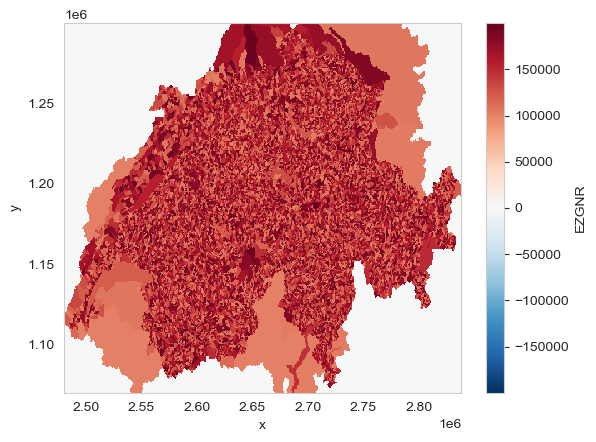

In [ ]:
grid_pt_in_polygon.plot()

## Aggregate streamflow at polygon

### Binary intersection

In [ ]:
# Converting streamflow to accumulated streamflow per polygon
streamflow_grid_resolution = 500  # in m
relevant_polygons = processing.gdf_polygons.EZGNR.to_numpy()
print("Computing accumulated streamflow")
path_rgs = processing.path_data_prevah / "rgs.zarr"
ds_rgs = (
    xr.open_zarr(path_rgs, chunks="auto")
    .sel(time="2005")
    .apply(
        lambda v: xr.apply_ufunc(
            data_processing_projections.convert_mm_d_to_cubic_m_s,
            v,
            streamflow_grid_resolution**2,
            vectorize=True,
            dask="parallelized",
            output_dtypes=[v.dtype],
        )
    )
)
# round coordinates to nearest grid resolution to match mask/grid (500 m)
res = streamflow_grid_resolution
new_x = (np.round(ds_rgs.x.values / res) * res).astype(ds_rgs.x.dtype)
new_y = (np.round(ds_rgs.y.values / res) * res).astype(ds_rgs.y.dtype)
ds_rgs = ds_rgs.assign_coords(x=new_x, y=new_y)
print(f"Rounded coordinates to nearest {res} m.")
ds_rgs

Computing accumulated streamflow
Rounded coordinates to nearest 500 m.


<xarray.Dataset> Size: 958MB
Dimensions:  (time: 365, y: 459, x: 715)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31
  * x        (x) float64 6kB 2.481e+06 2.482e+06 ... 2.838e+06 2.838e+06
  * y        (y) float64 4kB 1.3e+06 1.299e+06 1.298e+06 ... 1.071e+06 1.07e+06
Data variables:
    rgs      (time, y, x) float64 958MB dask.array<chunksize=(361, 256, 256), meta=np.ndarray>

In [ ]:
chunks_spatial = {
    "x": data_processing_projections.mode_of(ds_rgs.chunks["x"])[0],
    "y": data_processing_projections.mode_of(ds_rgs.chunks["y"])[0],
}
with ProgressBar(dt=10):
    ds_accum = (
        data_processing_projections.aggregate_streamflow_with_mask(
            ds_rgs,
            processing.grid_pt_in_polygon.chunk(chunks_spatial),
            method="sum",
            fill_value=-1,
            polygons=relevant_polygons,
        )
    ).compute()

[                                        ] | 0% Completed | 289.02 us

KeyboardInterrupt: 

In [ ]:
new_end_time = ds_accum.time[-1] + np.timedelta64(23, "h")
ds_accum_hourly = ds_accum.reindex(
    time=pd.date_range(
        start=ds_accum.time[0].values,
        end=new_end_time.values,
        freq="1H",
        inclusive="both",
    ),
    method="ffill",
)
ds_accum_hourly = ds_accum_hourly.sel(
    time=~(ds_accum_hourly.time.dt.month == 2) & ~(ds_accum_hourly.time.dt.day == 29)
)

/tmp/ipykernel_29146/2633881232.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time=pd.date_range(


In [ ]:
ds_accum_hourly_old = xr.open_dataset(
    "/landclim/yhaddad/paper1/data/prevah/ds_prevah_500_streamflow_accum_per_polygon_hourly.nc"
)

In [ ]:
ds_accum_hourly_old

<xarray.Dataset> Size: 49GB
Dimensions:  (time: 280320, polygon: 21858)
Coordinates:
  * time     (time) datetime64[ns] 2MB 1991-01-01 ... 2022-12-31T23:00:00
  * polygon  (polygon) int64 175kB 100001 100002 100003 ... 199987 199991 199993
Data variables:
    rgs      (polygon, time) float64 49GB ...

### Partial intersection

In [ ]:
relevant_polygons = processing.gdf_polygons.EZGNR.to_numpy()
if processing.df_prevah_pts_in_polygons is None:
    processing.df_prevah_pts_in_polygons = pd.read_csv(
        processing.path_data_polygons / df_prevah_pts_in_polygons_filename
    )

# Converting streamflow to accumulated streamflow per polygon
print("Computing accumulated streamflow")
ds_rgs = xr.open_zarr(processing.path_data_prevah / "rgs.zarr", chunks="auto")
new_x = (
    np.round(ds_rgs.x.values / prevah_grid_resolution) * prevah_grid_resolution
).astype(ds_rgs.x.dtype)
new_y = (
    np.round(ds_rgs.y.values / prevah_grid_resolution) * prevah_grid_resolution
).astype(ds_rgs.y.dtype)
ds_rgs = ds_rgs.assign_coords(x=new_x, y=new_y)

ds_rgs = ds_rgs.apply(
    lambda v: xr.apply_ufunc(
        convert_mm_d_to_cubic_m_s,
        v,
        prevah_grid_resolution**2,
        vectorize=True,
        dask="parallelized",
        output_dtypes=[v.dtype],
    )
)

chunks_spatial = {
    "x": ds_rgs.chunks["x"][0],
    "y": ds_rgs.chunks["y"][0],
    "polygon": 1000,
}
if processing.df_prevah_pts_in_polygons is not None:
    if processing.weighted:
        print("Using fractional weights for polygon-grid cell mapping.")
        if processing.grid_pt_in_polygon is None:
            processing.create_polygon_weight_array(
                ds_rgs,
                processing.df_prevah_pts_in_polygons.copy(),
                output_filename=None,
            )
    else:
        print(
            "No weights found, assuming uniform weights for polygon-grid cell mapping."
        )
        if processing.grid_pt_in_polygon is None:
            processing.create_prevah_polygon_grid(
                df_pts=processing.df_prevah_pts_in_polygons.copy(),
                fill_value=-1,
            )
processing.grid_pt_in_polygon = processing.grid_pt_in_polygon.chunk(chunks_spatial)

Computing accumulated streamflow
Using fractional weights for polygon-grid cell mapping.


In [ ]:
# remove leap days (Feb 29) from ds_rgs
len(
    ds_rgs.sel(time=~((ds_rgs.time.dt.month == 2) & (ds_rgs.time.dt.day == 29))).time
) / 365

32.0

In [ ]:
ds_rgs["rgs"].isel(time=0).fillna(0).dot(
    processing.grid_pt_in_polygon.isel(polygon=0)
).compute()

<xarray.DataArray ()> Size: 8B
array(0.0509378)
Coordinates:
    time     datetime64[ns] 8B 1991-01-01
    polygon  int64 8B 100001

In [ ]:
(
    ds_rgs["rgs"].isel(time=0) * processing.grid_pt_in_polygon.isel(polygon=0)
).sum().compute()

<xarray.DataArray ()> Size: 8B
array(0.0509378)
Coordinates:
    time     datetime64[ns] 8B 1991-01-01
    polygon  int64 8B 100001

In [ ]:
with ProgressBar(dt=10):
    accum_vars = {
        var: xr.dot(
            ds_rgs[var].isel(time=slice(0, 365)),
            processing.grid_pt_in_polygon.isel(polygon=slice(0, 1000)),
            dims=("y", "x"),
        )
        for var in ds_rgs.data_vars
    }
    ds_accum = xr.Dataset(accum_vars).persist()

[########################################] | 100% Completed | 272.97 s


In [ ]:
with ProgressBar(dt=10):
    accum_vars = {
        var: xr.dot(
            ds_rgs[var].isel(time=slice(0, 30)).fillna(0),
            processing.grid_pt_in_polygon.isel(polygon=slice(0, 1000)),
            dims=("y", "x"),
        )
        for var in ds_rgs.data_vars
    }
    ds_accum = xr.Dataset(accum_vars).persist()

[                                        ] | 0% Completed | 383.26 us

[########################################] | 100% Completed | 255.75 s


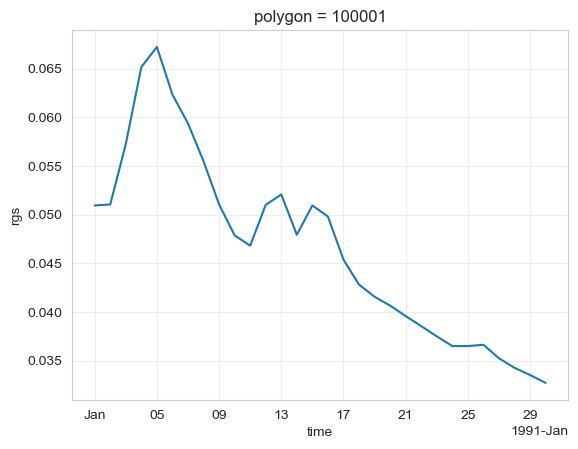

In [20]:
ds_accum.isel(polygon=0).rgs.plot()

### Comparison

In [ ]:
ds_accum = xr.open_zarr(
    processing.path_data_prevah
    / "ds_prevah_streamflow_accum_per_polygon_weighted.zarr",
    chunks="auto",
)

In [30]:
ds_accum_hourly_old = xr.open_dataset(
    "/landclim/yhaddad/papers/paper1_clim2ror/data/prevah/ds_prevah_500_streamflow_accum_per_polygon_hourly.nc"
)

In [34]:
# Faster alternative: pick the hourly records at midnight that match ds_accum daily timestamps.
# This avoids the expensive resample and stays lazy (dask/xarray will only load required chunks).
ds_accum_old_daily = ds_accum_hourly_old.sel(time=ds_accum.time)

# Ensure time coord matches and dims order is (time, polygon) like ds_accum
ds_accum_old_daily = ds_accum_old_daily.assign_coords(time=ds_accum.time)

ds_accum_old_daily

<xarray.Dataset> Size: 2GB
Dimensions:  (polygon: 21858, time: 10432)
Coordinates:
  * polygon  (polygon) int64 175kB 100001 100002 100003 ... 199987 199991 199993
  * time     (time) datetime64[ns] 83kB 1991-01-01 1991-01-02 ... 2022-12-31
Data variables:
    rgs      (polygon, time) float64 2GB ...

In [65]:
# Build daily date range 1991-01-01 .. 2022-12-31 excluding leap days and compare to ds_accum.time
dates = pd.date_range(start="1991-01-01", end="2022-12-31", freq="D")
dates_noleap = dates[~((dates.month == 2) & (dates.day == 29))]

ds_time = pd.DatetimeIndex(ds_accum.time.values)

print("constructed no-leap range length:", len(dates_noleap))
print("ds_accum.time length:           ", len(ds_time))

missing_in_ds = dates_noleap.difference(ds_time)
extra_in_ds = ds_time.difference(dates_noleap)

print("dates in constructed range not in ds_accum.time:", len(missing_in_ds))
if len(missing_in_ds):
    print(" examples:", missing_in_ds[:5].tolist())

print("dates in ds_accum.time not in constructed range:", len(extra_in_ds))
if len(extra_in_ds):
    print(" examples:", extra_in_ds[:5].tolist())

if len(missing_in_ds) == 0 and len(extra_in_ds) == 0:
    print("Time coordinates match exactly (no leap days).")
else:
    print("Mismatch detected. Inspect `missing_in_ds` and `extra_in_ds` for details.")

constructed no-leap range length: 11680
ds_accum.time length:            10432
dates in constructed range not in ds_accum.time: 1248
 examples: [Timestamp('1991-01-29 00:00:00'), Timestamp('1991-02-01 00:00:00'), Timestamp('1991-02-02 00:00:00'), Timestamp('1991-02-03 00:00:00'), Timestamp('1991-02-04 00:00:00')]
dates in ds_accum.time not in constructed range: 0
Mismatch detected. Inspect `missing_in_ds` and `extra_in_ds` for details.


In [68]:
missing_in_ds

DatetimeIndex(['1991-01-29', '1991-02-01', '1991-02-02', '1991-02-03',
               '1991-02-04', '1991-02-05', '1991-02-06', '1991-02-07',
               '1991-02-08', '1991-02-09',
               ...
               '2022-03-29', '2022-04-29', '2022-05-29', '2022-06-29',
               '2022-07-29', '2022-08-29', '2022-09-29', '2022-10-29',
               '2022-11-29', '2022-12-29'],
              dtype='datetime64[ns]', length=1248, freq=None)

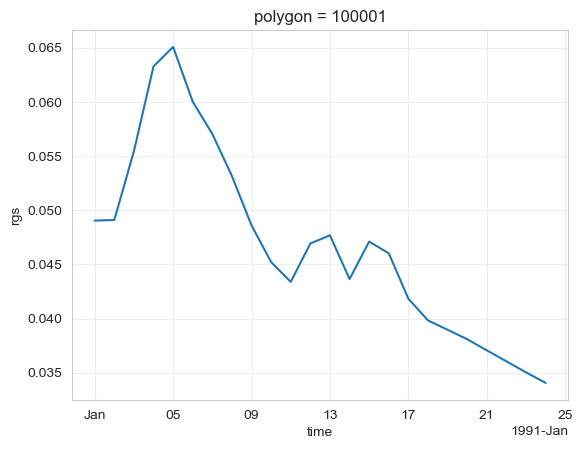

In [35]:
ds_accum_old_daily.isel(polygon=0, time=slice(0, 24)).rgs.plot()

#### Metrics

In [ ]:
ds_accum = xr.open_zarr(
    processing.path_data_prevah
    / "ds_prevah_streamflow_accum_per_polygon_weighted.zarr",
    chunks="auto",
)

ds_accum_hourly_old = xr.open_dataset(
    "/landclim/yhaddad/papers/paper1_clim2ror/data/prevah/ds_prevah_500_streamflow_accum_per_polygon_hourly.nc"
)
ds_accum_old_daily = ds_accum_hourly_old.sel(time=ds_accum.time)

# Ensure time coord matches and dims order is (time, polygon) like ds_accum
ds_accum_old_daily = ds_accum_old_daily.assign_coords(time=ds_accum.time)

ds_accum_old_daily = ds_accum_old_daily.chunk(
    {"time": ds_accum.chunks["time"][0], "polygon": ds_accum.chunks["polygon"][0]}
)

# Extract dataarrays
da_new = ds_accum["rgs"]
da_old = ds_accum_old_daily["rgs"]

# Ensure dims order (time, polygon)
if ("time" in da_new.dims) and ("polygon" in da_new.dims):
    da_new = da_new.transpose("time", "polygon")
if ("time" in da_old.dims) and ("polygon" in da_old.dims):
    da_old = da_old.transpose("time", "polygon")

# Align coordinates exactly to new dataset (safe indexing)
da_old = da_old.sel(time=da_new.time, polygon=da_new.polygon)

In [ ]:
# Compute per-polygon summary metrics (lazy with dask; will compute when .compute() called)
with ProgressBar(dt=5):
    # Compute difference (new - old)
    diff = da_new - da_old
    eps = 1e-12
    mean_abs = np.abs(diff).mean(dim="time")
    rmse = np.sqrt((diff**2).mean(dim="time"))
    max_abs = np.abs(diff).max(dim="time")
    # relative mean absolute difference wrt old values (avoid divide by zero)
    mean_rel = (np.abs(diff) / (np.abs(da_old) + eps)).mean(dim="time")
    # fraction of time where relative diff > 10%
    frac_exceed_10pct = ((np.abs(diff) / (np.abs(da_old) + eps)) > 0.1).mean(dim="time")

    # Build a pandas DataFrame with results (compute once)
    df_metrics = (
        xr.Dataset(
            {
                "mean_abs": mean_abs,
                "rmse": rmse,
                "max_abs": max_abs,
                "mean_rel": mean_rel,
                "frac_exceed_10pct": frac_exceed_10pct,
            }
        )
        .to_dataframe()
        .reset_index()
    )

    # Sort by different criteria and show top results
    n_top = 20
    print(f"Top {n_top} polygons by mean absolute difference:")
    print(df_metrics.sort_values("mean_abs", ascending=False).head(n_top))

    print(f"Top {n_top} polygons by RMSE:")
    print(df_metrics.sort_values("rmse", ascending=False).head(n_top))

    print(f"Top {n_top} polygons by max absolute difference:")
    print(df_metrics.sort_values("max_abs", ascending=False).head(n_top))

    # Save metrics for further inspection
    df_metrics.to_csv(
        "../data/comparison_ds_accum_vs_old_daily_per_polygon.csv", index=False
    )
    print(
        "Saved per-polygon metrics to:",
        "../data/comparison_ds_accum_vs_old_daily_per_polygon.csv",
    )

[########################################] | 100% Completed | 120.04 s
[########################################] | 100% Completed | 120.04 s
[########################################] | 100% Completed | 120.04 s
[########################################] | 100% Completed | 120.04 s
[########################################] | 100% Completed | 120.04 s
Top 20 polygons by mean absolute difference:
       polygon  mean_abs      rmse   max_abs  mean_rel  frac_exceed_10pct
10734   148554  0.087461  0.115258  0.294692  0.509978           0.934624
21497   198331  0.082111  0.126485  0.558248  0.026357           0.000000
56      100195  0.075516  0.118576  1.281088  0.005849           0.000000
8659    138899  0.075307  0.106232  0.690206  0.188115           0.993194
2664    110718  0.066042  0.095337  0.491522  0.167517           0.821894
7999    135801  0.065442  0.098565  0.501641  0.697968           0.849789
17876   181438  0.063705  0.100691  0.741229  0.159614           0.955330
3728    

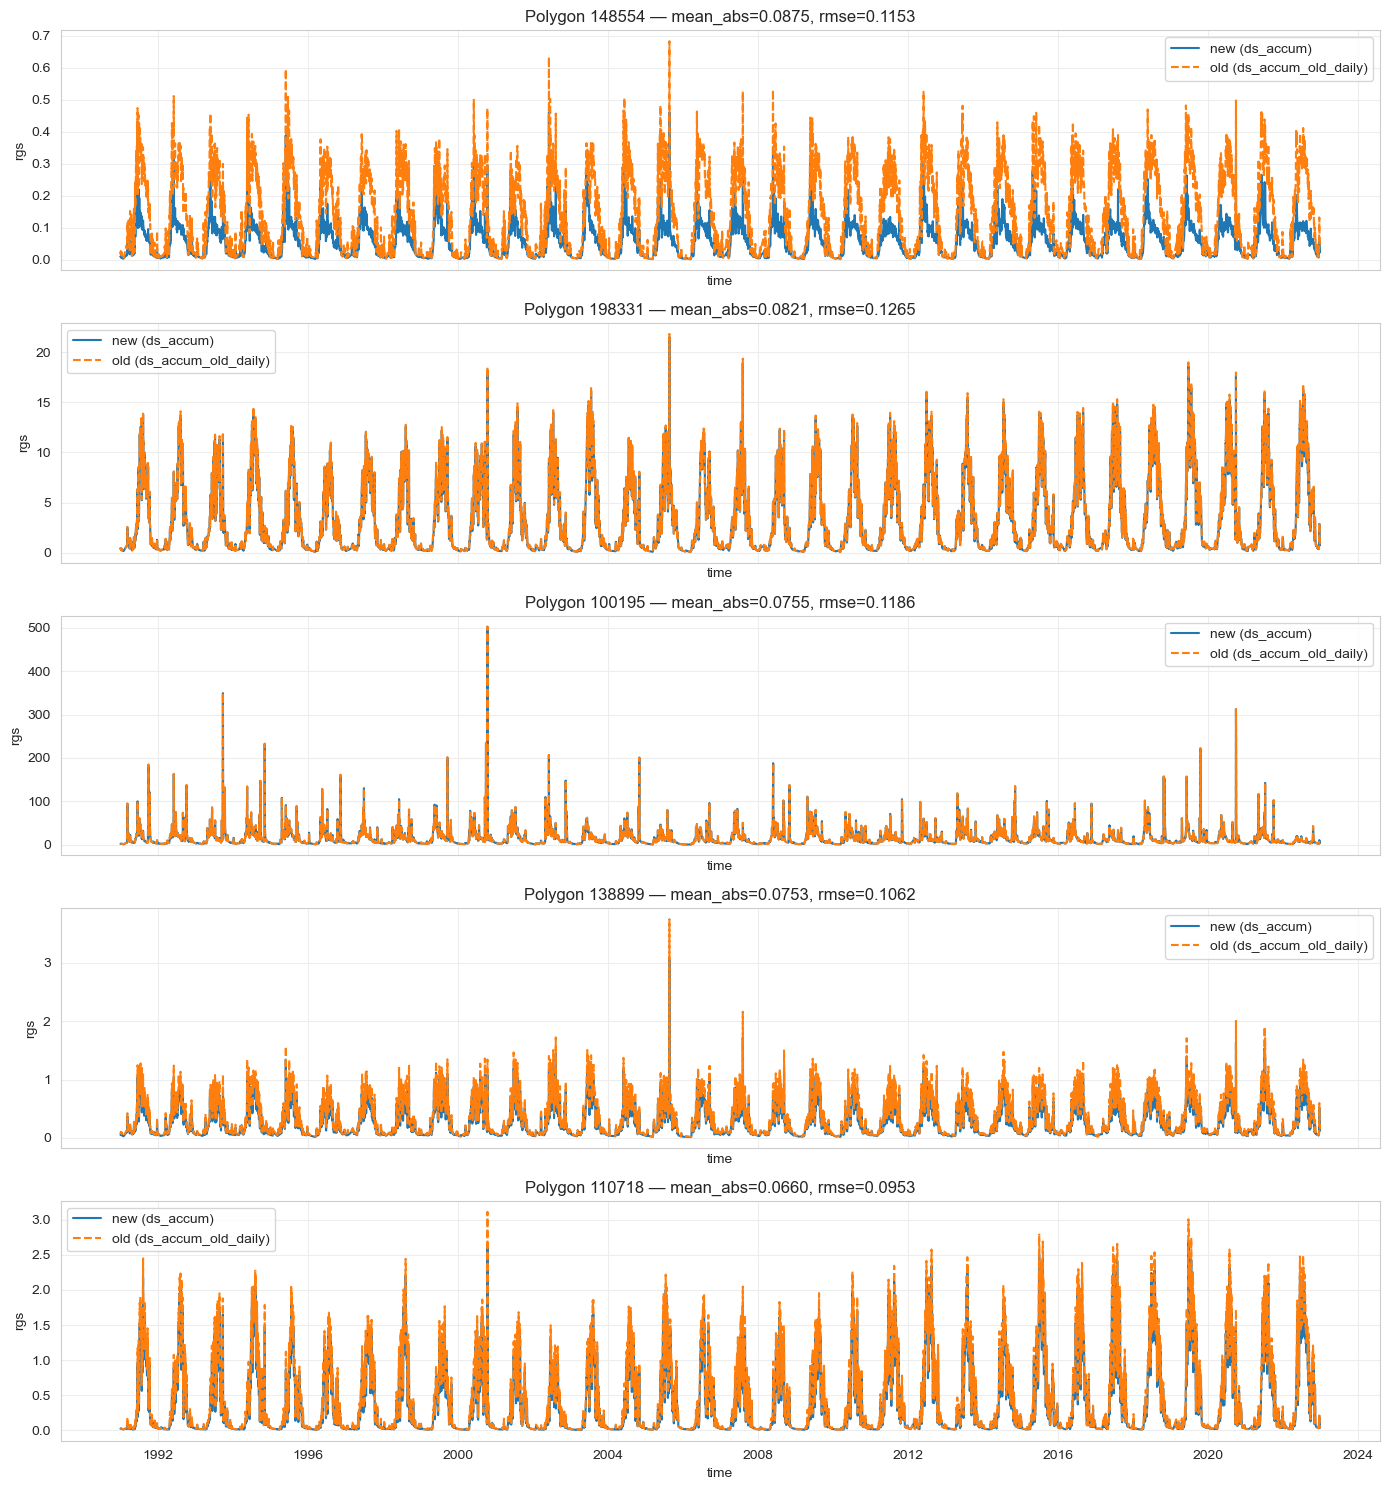

In [ ]:
df_metrics = pd.read_csv("../data/comparison_ds_accum_vs_old_daily_per_polygon.csv")

# Quick plots for the worst polygons (by mean_abs)
top_polygons = (
    df_metrics.sort_values("mean_abs", ascending=False).head(5)["polygon"].values
)

fig, axes = plt.subplots(
    len(top_polygons), 1, figsize=(14, 3 * len(top_polygons)), sharex=True
)
if len(top_polygons) == 1:
    axes = [axes]

for ax, pid in zip(axes, top_polygons):
    da_new.sel(polygon=pid).plot(ax=ax, label="new (ds_accum)", color="C0")
    da_old.sel(polygon=pid).plot(
        ax=ax, label="old (ds_accum_old_daily)", color="C1", linestyle="--"
    )
    ax.set_title(
        f"Polygon {int(pid)} — mean_abs={df_metrics.loc[df_metrics.polygon==pid,'mean_abs'].values[0]:.4f}, rmse={df_metrics.loc[df_metrics.polygon==pid,'rmse'].values[0]:.4f}"
    )
    ax.legend()

plt.tight_layout()
plt.show()

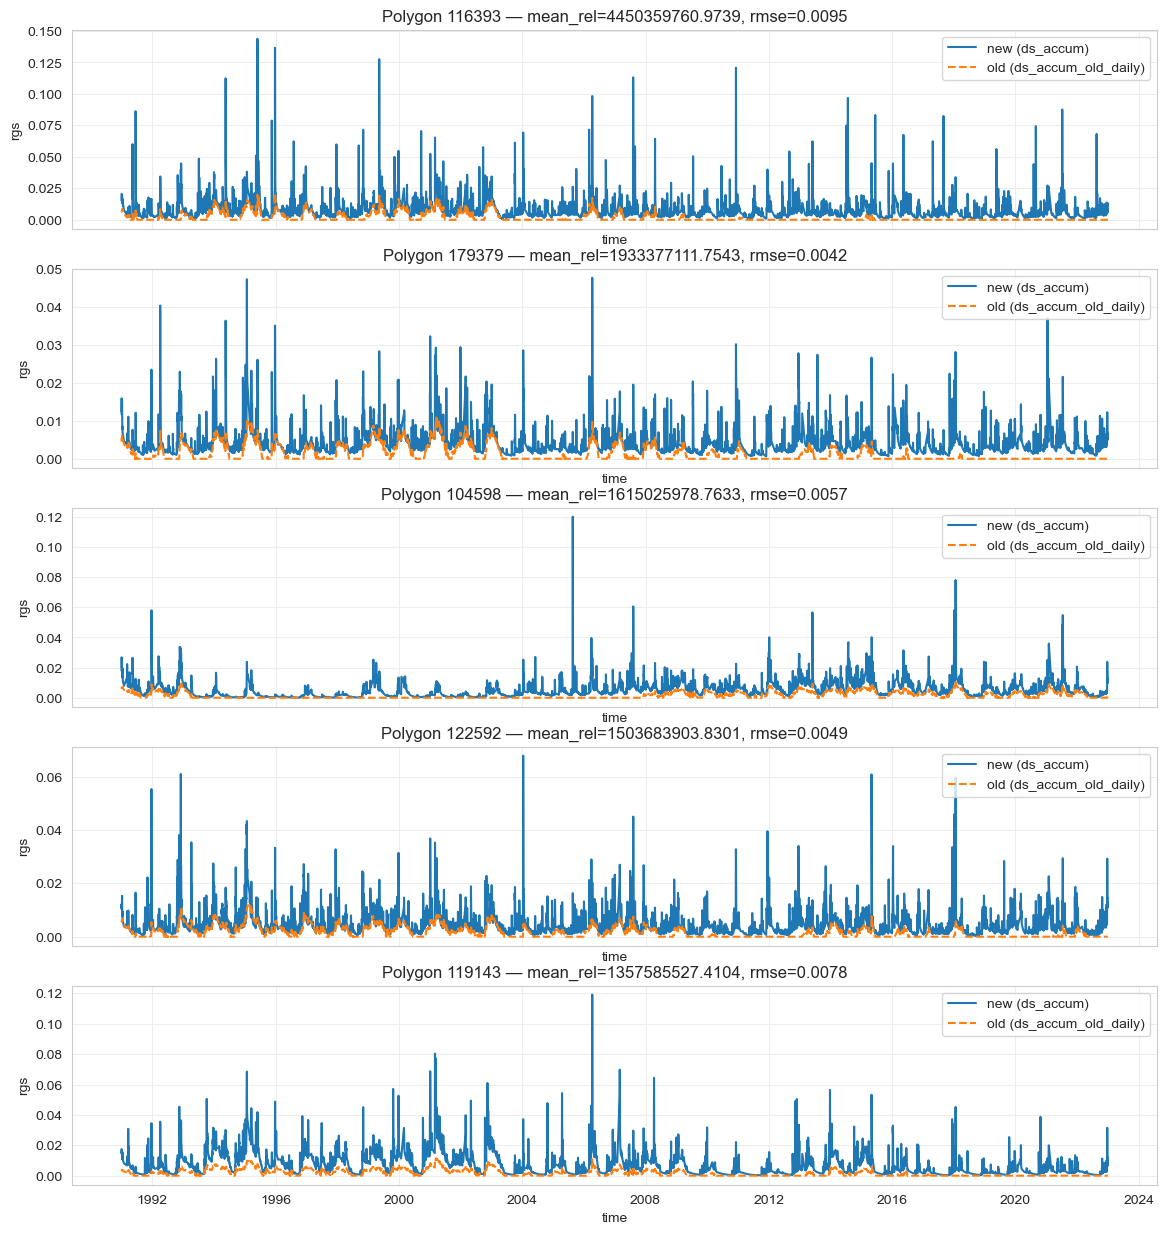

In [ ]:
# Quick plots for the worst polygons (by mean_rel)
top_polygons = (
    df_metrics.sort_values("mean_rel", ascending=False).head(5)["polygon"].values
)

fig, axes = plt.subplots(
    len(top_polygons), 1, figsize=(14, 3 * len(top_polygons)), sharex=True
)
if len(top_polygons) == 1:
    axes = [axes]

for ax, pid in zip(axes, top_polygons):
    da_new.sel(polygon=pid).plot(ax=ax, label="new (ds_accum)", color="C0")
    da_old.sel(polygon=pid).plot(
        ax=ax, label="old (ds_accum_old_daily)", color="C1", linestyle="--"
    )
    ax.set_title(
        f"Polygon {int(pid)} — mean_rel={df_metrics.loc[df_metrics.polygon==pid,'mean_rel'].values[0]:.4f}, rmse={df_metrics.loc[df_metrics.polygon==pid,'rmse'].values[0]:.4f}"
    )
    ax.legend()

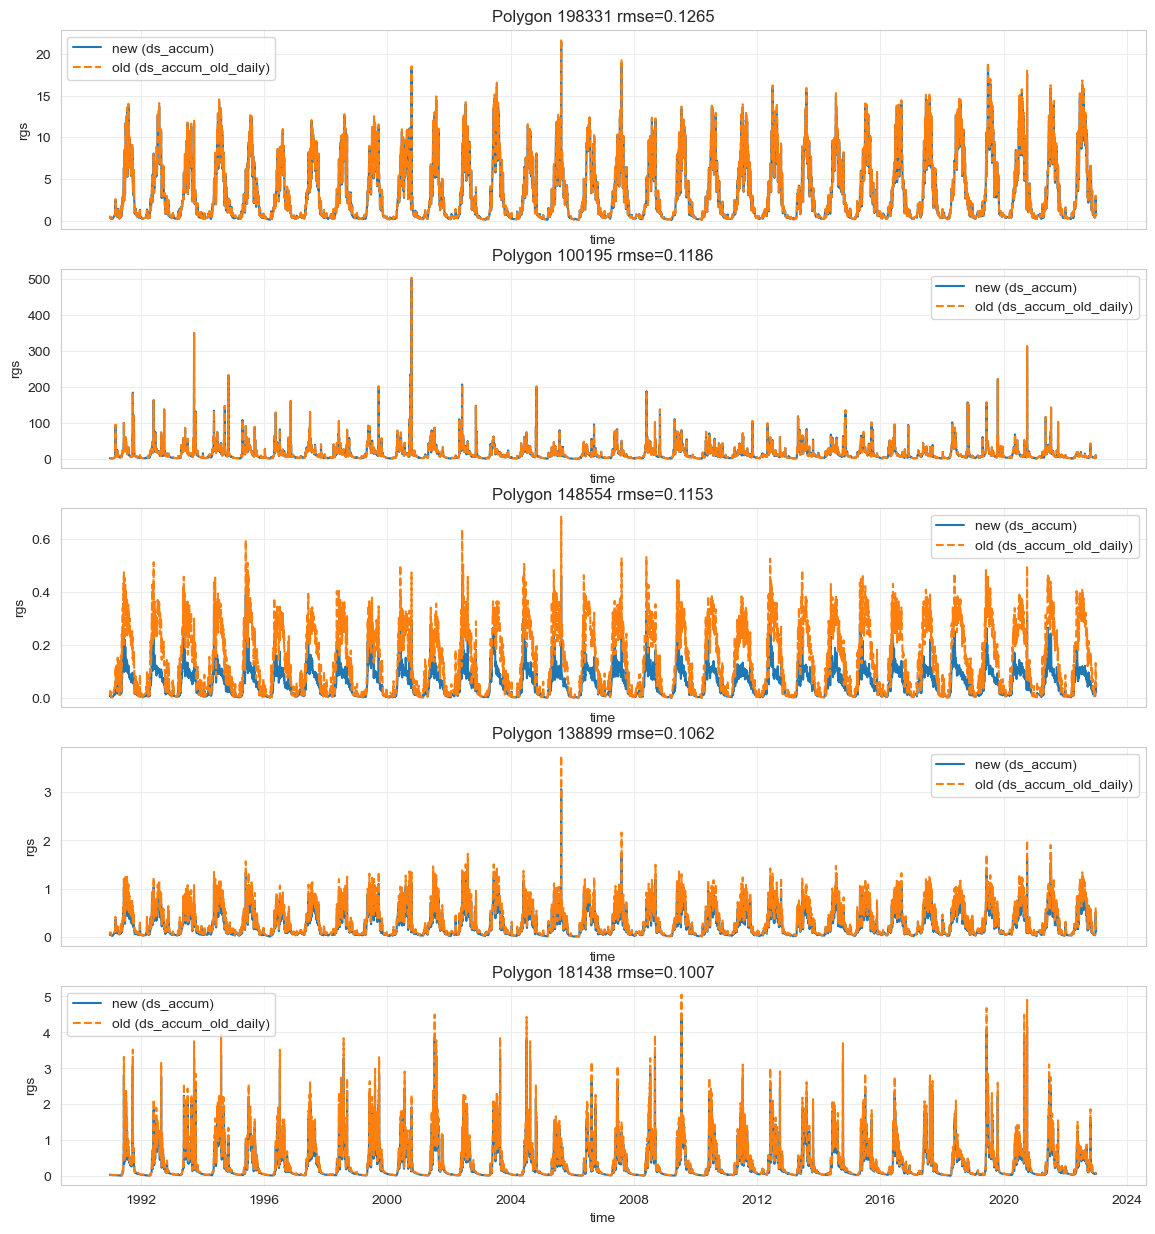

In [ ]:
# Quick plots for the worst polygons (by rmse)
top_polygons = df_metrics.sort_values("rmse", ascending=False).head(5)["polygon"].values

fig, axes = plt.subplots(
    len(top_polygons), 1, figsize=(14, 3 * len(top_polygons)), sharex=True
)
if len(top_polygons) == 1:
    axes = [axes]

for ax, pid in zip(axes, top_polygons):
    da_new.sel(polygon=pid).plot(ax=ax, label="new (ds_accum)", color="C0")
    da_old.sel(polygon=pid).plot(
        ax=ax, label="old (ds_accum_old_daily)", color="C1", linestyle="--"
    )
    ax.set_title(
        f"Polygon {int(pid)} rmse={df_metrics.loc[df_metrics.polygon==pid,'rmse'].values[0]:.4f}"
    )
    ax.legend()

## Build hydropower parameter table

In [9]:
df_hydropower_polygons = pd.read_json(
    processing.path_data_hydro / "hydropower_polygons" / "df_hydropower_polygons.json",
    orient="records",
)

hp_param_df = data_processing_projections.build_hydropower_parameter_table(
    processing.df_stats_hydropower_ch, df_hydropower_polygons, allowed_types=["L"]
)

## Build hydropower polygon matrix

In [ ]:
ds_accum = xr.open_zarr(
    processing.path_data_prevah
    / "ds_prevah_streamflow_accum_per_polygon_weighted.zarr",
    chunks="auto",
)

In [25]:
ds_accum_diff = diff.to_dataset()

In [ ]:
dtype = "uint8"
polygon_col = "polygons_full"
plant_id_col = "WASTANumber"
polygons_all = ds_accum.polygon.values
hp_param_df = data_processing_projections.build_hydropower_parameter_table(
    processing.df_stats_hydropower_ch, df_hydropower_polygons, allowed_types=["L"]
)
polygon_plant_weights = build_polygon_plant_weights(
    polygons_all, hp_param_df, polygon_col, plant_id_col, dtype=dtype
)

In [41]:
polygon_plant_weights

<xarray.DataArray 'weights' (polygon: 21858, hydropower: 601)> Size: 13MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
Coordinates:
  * polygon     (polygon) int64 175kB 100001 100002 100003 ... 199991 199993
  * hydropower  (hydropower) int64 5kB 100100 100125 100150 ... 900100 900200

In [107]:
polygon_plant_weights.sum("hydropower")

<xarray.DataArray 'weights' (polygon: 21858)> Size: 175kB
array([ 1,  7, 15, ...,  0, 32, 27], dtype=uint64)
Coordinates:
  * polygon  (polygon) int64 175kB 100001 100002 100003 ... 199987 199991 199993

## Compute generation

In [42]:
ds_accum_daily = xr.open_zarr(
    processing.path_data_prevah
    / "ds_prevah_streamflow_accum_per_polygon_weighted.zarr",
    chunks="auto",
)

In [58]:
with ProgressBar(dt=5):
    ds_gen = compute_hydropower_production_vectorized(
        ds_accum_daily,
        hp_param_df,
        variable="rgs",
        timestep_hours=24,
        use_simplified_efficiency=True,
    ).compute()

[########################################] | 100% Completed | 10.02 s


In [59]:
ds_gen.sel(time="2005").gen.sum("hydropower").sum("time")

<xarray.DataArray 'gen' ()> Size: 8B
array(17.25860871)

In [45]:
ds_gen_old = xr.open_dataset(
    "/landclim/yhaddad/papers/paper1_clim2ror/data/hydropower/hydropower_generation/ds_prevah_500_hydropower_production_ror_simplified_efficiency.nc"
)

In [46]:
ds_gen_old.sel(time="2005").sum()

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    gen      float64 8B 17.32

In [47]:
df_reported_generation = pd.read_csv(
    processing.path_data_ror
    / "energy"
    / "ogd35_schweizerische_elektrizitaetsbilanz_monatswerte.csv"
)
df_reported_generation_ror = df_reported_generation[df_reported_generation.Jahr < 2023][
    ["Jahr", "Monat", "Erzeugung_laufwerk_GWh"]
]
df_reported_generation_ror["Erzeugung_laufwerk_GWh"] *= 1e-3  # to TWh

In [48]:
list_ds = []
hp_in_ds = ds_gen.hydropower.to_numpy()
for i in np.unique(ds_gen.time.dt.year):
    wasta = processing.gdf_hydropower_locations[
        (processing.gdf_hydropower_locations["BeginningOfOperation"] <= i)
        & (processing.gdf_hydropower_locations["WASTANumber"].isin(hp_in_ds))
    ]["WASTANumber"].tolist()
    list_ds.append(
        ds_gen.sel(hydropower=wasta, time=str(i))
        .resample(time="ME")
        .sum(["hydropower", "time"])
    )
ds_hydropower_generation_per_month = xr.concat(list_ds, dim="time")

df_reported_generation_ror["Estimated Generation_New"] = (
    ds_hydropower_generation_per_month.sel(time=slice("2000", None)).gen.to_numpy()
)

list_ds = []
hp_in_ds = ds_gen_old.hydropower.to_numpy()
for i in np.unique(ds_gen_old.time.dt.year):
    wasta = processing.gdf_hydropower_locations[
        (processing.gdf_hydropower_locations["BeginningOfOperation"] <= i)
        & (processing.gdf_hydropower_locations["WASTANumber"].isin(hp_in_ds))
    ]["WASTANumber"].tolist()
    list_ds.append(
        ds_gen_old.sel(hydropower=wasta, time=str(i))
        .resample(time="ME")
        .sum(["hydropower", "time"])
    )
ds_hydropower_generation_per_month_old = xr.concat(list_ds, dim="time")

df_reported_generation_ror["Estimated Generation_Old"] = (
    ds_hydropower_generation_per_month_old.sel(time=slice("2000", None)).gen.to_numpy()
)

In [49]:
df_reported_generation_ror["time"] = pd.date_range(
    start="2000-01-31", periods=len(df_reported_generation_ror), freq="ME"
)

Text(0.5, 1.0, 'Monthly Hydropower Generation: Reported vs Estimated (New and Old Methods)')

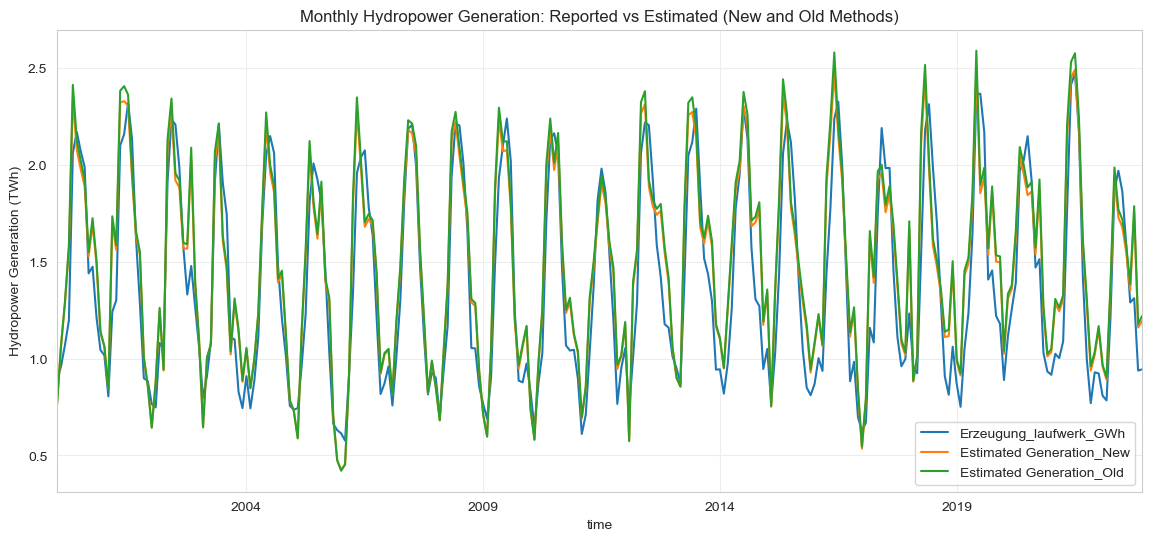

In [50]:
df_reported_generation_ror.plot(
    x="time",
    y=[
        "Erzeugung_laufwerk_GWh",
        "Estimated Generation_New",
        "Estimated Generation_Old",
    ],
    figsize=(14, 6),
)
plt.ylabel("Hydropower Generation (TWh)")
plt.title("Monthly Hydropower Generation: Reported vs Estimated (New and Old Methods)")

Text(0.5, 1.0, 'Monthly Hydropower Generation: Reported vs Estimated (New and Old Methods)')

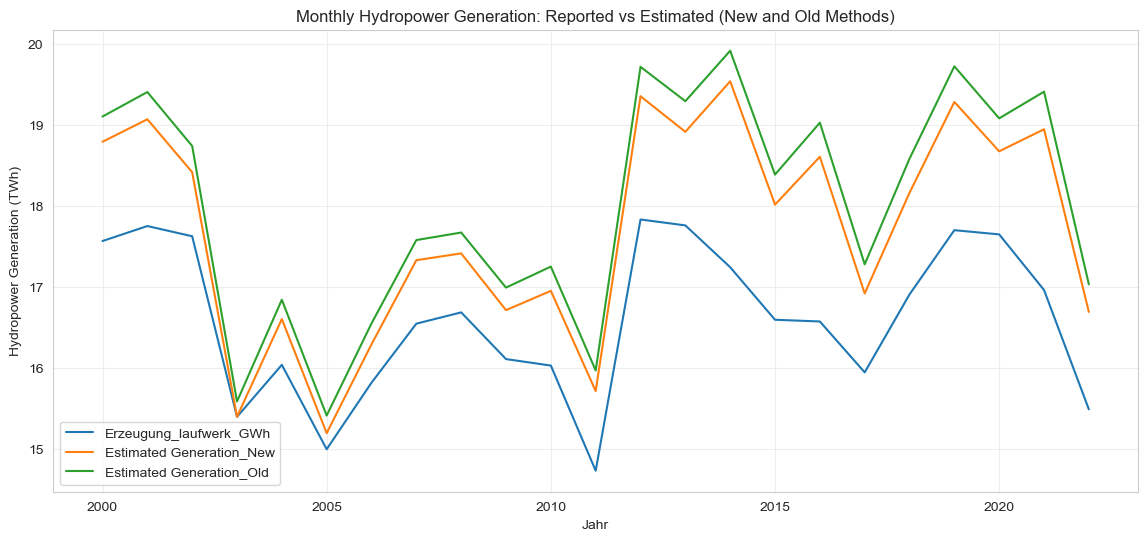

In [ ]:
df_reported_generation_ror.groupby("Jahr")[
    [
        "Erzeugung_laufwerk_GWh",
        "Estimated Generation_New",
        "Estimated Generation_Old",
    ]
].sum().plot(
    figsize=(14, 6),
)
plt.ylabel("Hydropower Generation (TWh)")
plt.title("Monthly Hydropower Generation: Reported vs Estimated (New and Old Methods)")

In [55]:
df_reported_generation_ror["Relative Bias"] = (
    df_reported_generation_ror["Estimated Generation_New"]
    / df_reported_generation_ror["Erzeugung_laufwerk_GWh"]
)
df_reported_generation_ror_monthly_mean = df_reported_generation_ror.groupby(
    "Monat"
).mean()
monthly_values = (
    1 / df_reported_generation_ror_monthly_mean["Relative Bias"]
).to_numpy()

In [56]:
monthly_values

array([0.94560235, 0.96548484, 0.8442383 , 0.83222989, 0.90241578,
       1.00798625, 1.10990839, 1.0583801 , 0.96588013, 0.82536808,
       0.81591139, 0.88851093])

In [ ]:
xr.open_dataset(
    "/landclim/yhaddad/papers/paper1_clim2ror/data/hydropower/hydropower_generation/ds_prevah_500_hydropower_production_ror_simplified_efficiency_monthly_bias_correction_factors.nc"
).sel(
    time=[
        "1991-01-01 00:00",
        "1991-02-01 00:00",
        "1991-03-01 00:00",
        "1991-04-01 00:00",
        "1991-05-01 00:00",
        "1991-06-01 00:00",
        "1991-07-01 00:00",
        "1991-08-01 00:00",
        "1991-09-01 00:00",
        "1991-10-01 00:00",
        "1991-11-01 00:00",
        "1991-12-01 00:00",
    ]
).bias_correction_factor.values

array([0.93891345, 0.9617325 , 0.83620765, 0.81779488, 0.88047987,
       0.98211679, 1.08624573, 1.03652785, 0.94853287, 0.81108352,
       0.80207831, 0.87809956])

### Projections

In [19]:
ds_gen_rcp26 = xr.open_zarr(
    processing.path_data_hydro
    / "hydropower_generation"
    / "ds_prevah_CNRM-ALADIN63_CNRM-CERFACS-CNRM-CM5_r1i1p1_rcp26_hydropower_production_ror.zarr",
    chunks="auto",
)

ds_gen_rcp85 = xr.open_zarr(
    processing.path_data_hydro
    / "hydropower_generation"
    / "ds_prevah_CNRM-ALADIN63_CNRM-CERFACS-CNRM-CM5_r1i1p1_rcp85_hydropower_production_ror.zarr",
    chunks="auto",
)

In [20]:
# yearly totals for rcp26
yearly_gen_rcp26 = ds_gen_rcp26.gen.resample(time="YE").sum(dim="time").sum(dim="hydropower")
yearly_da_rcp26 = yearly_gen_rcp26
df26 = yearly_da_rcp26.to_dataframe(name="gen_yearly").reset_index()
df26["year"] = df26["time"].dt.year
series26 = df26.set_index("year")["gen_yearly"]
yearly_values_rcp26 = series26.to_numpy()

# yearly totals for rcp85
yearly_gen_rcp85 = ds_gen_rcp85.gen.resample(time="YE").sum(dim="time").sum(dim="hydropower")
yearly_da_rcp85 = yearly_gen_rcp85
df85 = yearly_da_rcp85.to_dataframe(name="gen_yearly").reset_index()
df85["year"] = df85["time"].dt.year
series85 = df85.set_index("year")["gen_yearly"]
yearly_values_rcp85 = series85.to_numpy()

# combine into one dataframe (aligned by year)
df_combined = pd.merge(
    df26[["year", "gen_yearly"]],
    df85[["year", "gen_yearly"]],
    on="year",
    suffixes=("_rcp26", "_rcp85"),
)

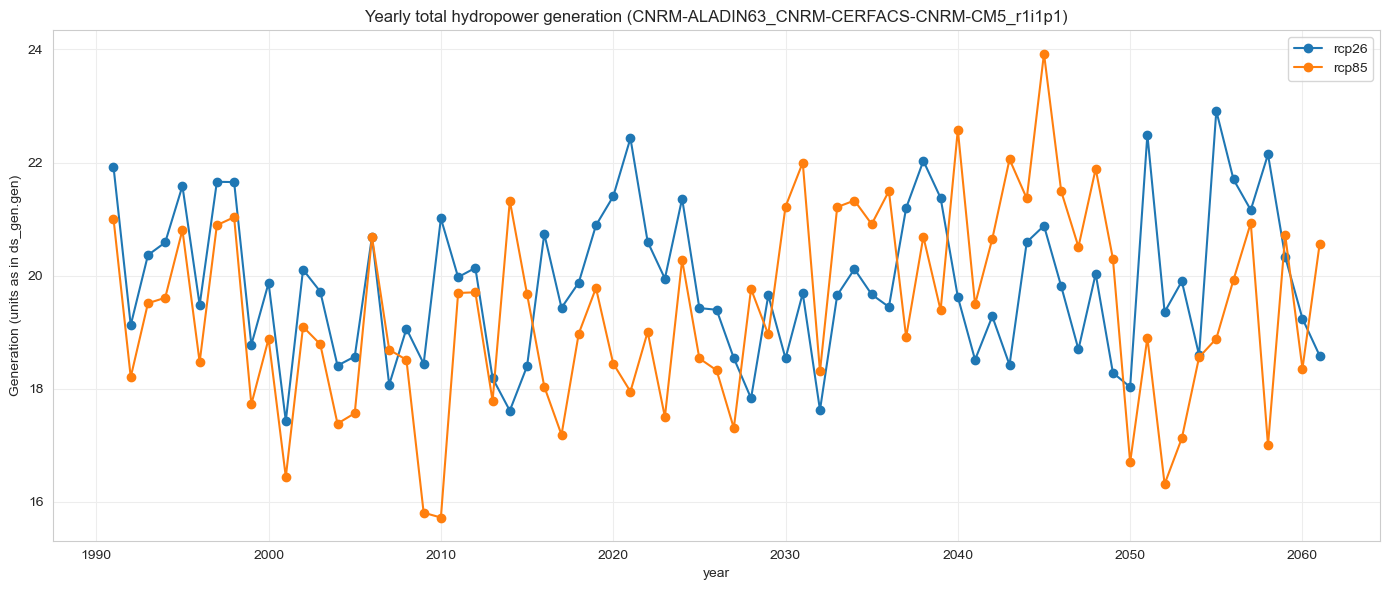

In [21]:
# plot both series
ax = df_combined.set_index("year").plot(
    figsize=(14, 6), marker="o", linestyle="-"
)
ax.set_title(f"Yearly total hydropower generation ({climate_model_chain})")
ax.set_ylabel("Generation (units as in ds_gen.gen)")
ax.legend(["rcp26", "rcp85"])
plt.tight_layout()

# keep yearly arrays/dataframe for further analysis
yearly_da = yearly_da_rcp26
yearly_df = df_combined.copy()
yearly_series = series26  # default reference remains rcp26
yearly_values = yearly_values_rcp26

In [25]:
from sklearn.linear_model import TheilSenRegressor
from scipy.stats.mstats import theilslopes

periods = {"1991-2020": (1991, 2020), "2021-2050": (2021, 2050)}
def compute_theilsen_trends(df, col, periods=periods, alpha=0.95):
    """Compute Theil-Sen trends for `col` in `df` for the requested periods.
    Returns a pandas DataFrame indexed by period (same columns as previous df_trends).
    """
    rows = []
    for name, (y0, y1) in periods.items():
        dfp = df[(df.year >= y0) & (df.year <= y1)].copy()
        if dfp.empty:
            raise ValueError(f"No data for period {name} and column {col}")

        X = dfp["year"].to_numpy().reshape(-1, 1)
        y = dfp[col].to_numpy()

        try:
            slope, intercept, lo_slope, hi_slope = theilslopes(y, dfp["year"].to_numpy(), alpha=alpha)
            method = f"scipy.theilslopes ({int(alpha*100)}% CI)"
        except Exception:
            model = TheilSenRegressor(random_state=0)
            model.fit(X, y)
            slope = float(model.coef_[0])
            intercept = float(model.intercept_)
            lo_slope, hi_slope = (np.nan, np.nan)
            method = "sklearn.TheilSenRegressor (no CI)"

        slope_per_year = float(slope)
        slope_per_decade = slope_per_year * 10.0
        mean_val = y.mean()
        rel_per_decade_pct = 100.0 * (slope_per_decade / mean_val)

        rows.append(
            {
                "period": name,
                "n_years": len(dfp),
                "slope_TWh_per_year": slope_per_year,
                "slope_TWh_per_decade": slope_per_decade,
                "slope_CI_lower": lo_slope,
                "slope_CI_upper": hi_slope,
                "mean_TWh": mean_val,
                "rel_change_pct_per_decade": rel_per_decade_pct,
                "method": method,
            }
        )

    return pd.DataFrame(rows).set_index("period")


# apply to both scenarios (rcp26 / rcp85) using the combined yearly_df
ds_trends_rcp26 = compute_theilsen_trends(yearly_df, "gen_yearly_rcp26")
ds_trends_rcp85 = compute_theilsen_trends(yearly_df, "gen_yearly_rcp85")

# keep per-scenario results and a combined lookup
ds_trends = pd.concat(
    [
        ds_trends_rcp26.assign(scenario="rcp26"),
        ds_trends_rcp85.assign(scenario="rcp85"),
    ]
).reset_index().set_index(["scenario", "period"])

display(ds_trends)

n_years  slope_TWh_per_year  slope_TWh_per_decade  \
scenario period                                                         
rcp26    1991-2020       30           -0.031323             -0.313226   
         2021-2050       30           -0.029396             -0.293960   
rcp85    1991-2020       30           -0.040766             -0.407657   
         2021-2050       30            0.101430              1.014301   

                    slope_CI_lower  slope_CI_upper   mean_TWh  \
scenario period                                                 
rcp26    1991-2020       -0.088276        0.038398  19.772241   
         2021-2050       -0.085737        0.020723  19.688822   
rcp85    1991-2020       -0.096916        0.027323  18.847630   
         2021-2050        0.031271        0.160778  20.134164   

                    rel_change_pct_per_decade                      method  
scenario period                                                            
rcp26    1991-2020                  -1.584171  scipy.theilslopes (95% CI)  
         2021-2050                  -1.493029  scipy.theilslopes (95% CI)  
rcp85    1991-2020                  -2.162910  scipy.theilslopes (95% CI)  
         2021-2050                   5.037711  scipy.theilslopes (95% CI)